In [1]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise

In [2]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX, DelimitedFiles, LinearAlgebra;

Your version of python is not linked to helper_scripts.py
Congratulations- Your version of python is linked to the Atomic Simulation Environment


In [3]:
# Ions are at (0, 0), (1/3, 2/3), so we have to put centers at (1/6, 1/3), (1/6, -1/6), (-1/3, -1/6)
# The center of the hexagon is at (2/3, 1/3)

In [3]:
Hwannier, cell_map = hwannier("wannier"), np.loadtxt("wannier.map.txt");
Pwannier = pwannier("wannier")
lattice_vectors = loadlattice("wannier.out");
kpoints = bandstructkpoints2q(interpolate=20);

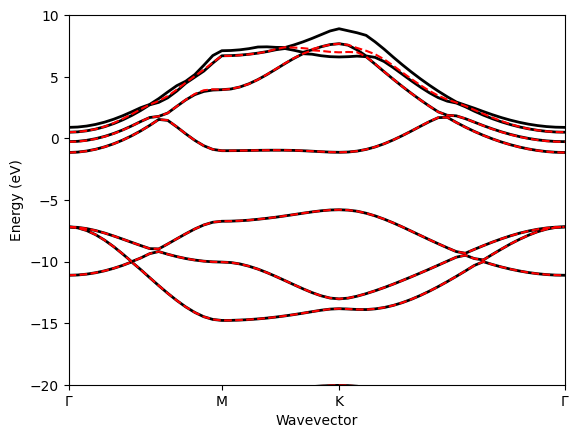

(-20.0, 10.0)

In [29]:
plot_bands("hBN.bands.eigenvals")
plot_bands(Hwannier, cell_map, color="red", linestyle="dashed")

ylim(-20, 10)

In [38]:
dot([1, 1im], [1, 1im])

2 + 0im

In [39]:
# Check overlaps
k = 0.15/6
q = 0.01/6
kpoints = Vector{Float64}[]
p_overlaps = Float64[]
wannier_overlaps = Float64[]
ediffs = Float64[]
N = 100
k_origin = [2/3, -1/3, 0]

band1 = 4
band2 = 5
for i in 1:N
    theta = 2π*i/N
    k1 = normalize_kvector(lattice_vectors, [k*cos(theta), k*sin(theta), 0])
    k2 = normalize_kvector(lattice_vectors, [k*cos(theta) + q, k*sin(theta), 0])
    e1s, U1s = wannier_bands(Hwannier, cell_map, k1 + k_origin)
    e2s, U2s = wannier_bands(Hwannier, cell_map, k2 + k_origin)
    e1 = e1s[band1]
    e2 = e2s[band2]
    U1 = U1s[:, band1]
    U2 = U2s[:, band2]
    push!(wannier_overlaps, (abs(dot(U1, U2 )))^2 )
    ediff = e2 - e1
    push!(p_overlaps, (abs(momentum_matrix_elements(Hwannier, cell_map, Pwannier, k1 + k_origin)[1, band1, band2]*ħ/mₑ))^2)
    push!(kpoints, k1+k_origin, k2+k_origin)
    push!(ediffs, e2-e1)
end

In [60]:
open("bandstruct.aroundK.kpoints", "w") do io
    for k in kpoints
        kx, ky, kz = k
        write(io, "kpoint $kx $ky $kz 0.005\n")
    end
end

In [5]:
ks, wk, iGarr = gvectors("hBN.aroundK");

In [6]:
filebase = "hBN.aroundK";
wfns = np.fromfile("$filebase.wfns", dtype=np.complex128);

In [24]:
k_wfns = Vector{ComplexF64}[]
kq_wfns = Vector{ComplexF64}[]
start_idx = 0
for (i, iGk) in enumerate(iGarr)
    numGs = length(iGk)
    if i % 2 == 0
        push!(kq_wfns, np.reshape(wfns[1+start_idx*8:(start_idx+numGs)*8], (8, numGs))[4, :])
    else
        push!(k_wfns, np.reshape(wfns[1+start_idx*8:(start_idx+numGs)*8], (8, numGs))[5, :])
    end
    start_idx += numGs
end

In [8]:
Gk_idxs = Vector{Int}[]
Gkq_idxs = Vector{Int}[]
for (iGk, iGkq) in zip(iGarr[1:2:end], iGarr[2:2:end])
    Gk_idx = Int[]
    Gkq_idx = Int[]
    for (i, G) in enumerate(iGk)
        idx = findfirst(x->isapprox(x, G), iGkq)
        isnothing(idx) && continue
        push!(Gk_idx, i)
        push!(Gkq_idx, idx)
    end
    push!(Gk_idxs, Gk_idx)
    push!(Gkq_idxs, Gkq_idx)
end

In [26]:
abinitio_overlaps = Float64[]
for (Gk_idx, Gkq_idx, k_wfn, kq_wfn) in zip(Gk_idxs, Gkq_idxs, k_wfns, kq_wfns)
    overlap = dot(kq_wfn[Gkq_idx], k_wfn[Gk_idx])*unit_cell_volume(lattice_vectors)/bohrtoangstrom^3
    overlap_sqrd = overlap*conj(overlap)
    push!(abinitio_overlaps, overlap_sqrd)
end

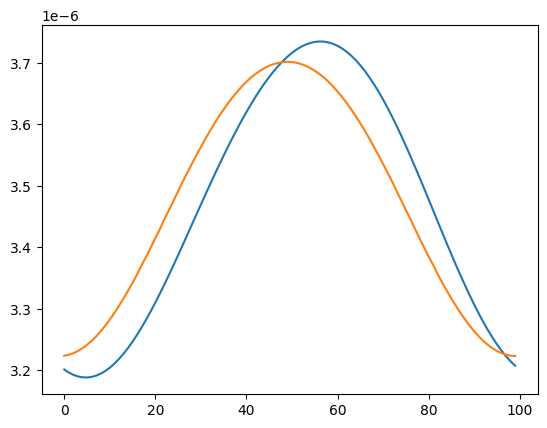

1-element Vector{PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7f3df411cee0>

In [42]:
plot(wannier_overlaps)
plot(abinitio_overlaps)

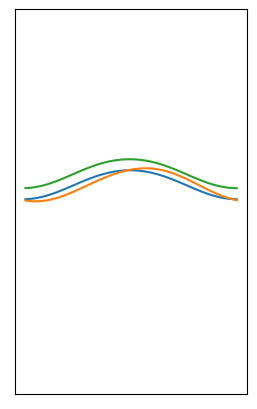

(Any[], Any[])

In [40]:
figure(figsize=(3, 5))
plot(abinitio_overlaps.*ediffs.^2/(0.01/6)^2)
plot(wannier_overlaps.*ediffs.^2/(0.01/6)^2)

plot(p_overlaps)
ylim(0, 50)
xticks([])
yticks([])

In [43]:
sigma_inter = interbandsigma(lattice_vectors, Hwannier, cell_map, 
    Pwannier, -3, Val(2); mesh=5, num_blocks=1,
    histogram_width=100, energy_range=33, degeneracy=2);

Block: 1


In [44]:
imag_conds = zeros(500)
start_idx = 2
for i in 1:500
    imag_conds[i] = real(kramers_kronig(i*3/500, collect(range(0, 33, length=3300))[start_idx:end], real.(sigma_inter[1, 1, start_idx:end]+sigma_inter[2, 2, start_idx:end]) ./ 2, Val(:real)))
end

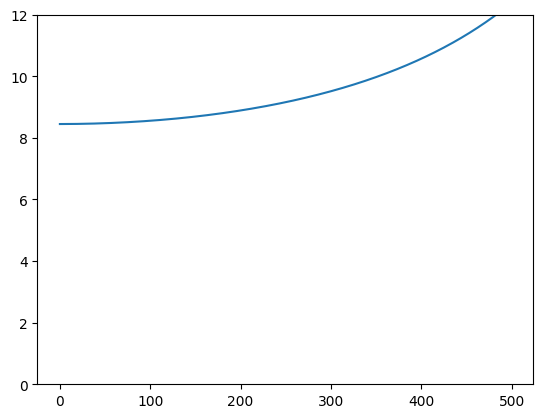

(0.0, 12.0)

In [45]:
plot(-1/bohrtoangstrom*e²ϵ/8*imag_conds ./  collect(range(3/500, 3, length=500)))
ylim(0, 12)

In [11]:
qs = norm.(unnormalize_kvector.(Ref(lattice_vectors), kpoints)[1:50])*bohrtoangstrom;

In [12]:
polarizations = []
for (i,k) in enumerate(kpoints[1:50])
    println(i); flush(stdout)
    push!(polarizations, ImΠ(Hwannier, cell_map, lattice_vectors, k, -3, Val(2), histogram_width=10, mesh=10, num_blocks=10, degeneracy=2, monte_carlo=true))
end

1
[0.0, 0.0, 0.0]
2
[0.0014705882353, 0.0, 0.0]
3
[0.0029411764706, 0.0, 0.0]
4
[0.0044117647059, 0.0, 0.0]
5
[0.0058823529412, 0.0, 0.0]
6
[0.0073529411765, 0.0, 0.0]
7
[0.0088235294118, 0.0, 0.0]
8
[0.0102941176471, 0.0, 0.0]
9
[0.0117647058824, 0.0, 0.0]
10
[0.0132352941177, 0.0, 0.0]
11
[0.014705882353, 0.0, 0.0]
12
[0.0161764705883, 0.0, 0.0]
13
[0.0176470588236, 0.0, 0.0]
14
[0.0191176470589, 0.0, 0.0]
15
[0.0205882352942, 0.0, 0.0]
16
[0.0220588235295, 0.0, 0.0]
17
[0.0235294117648, 0.0, 0.0]
18
[0.0250000000001, 0.0, 0.0]
19
[0.0264705882354, 0.0, 0.0]
20
[0.0279411764707, 0.0, 0.0]
21
[0.029411764706, 0.0, 0.0]
22
[0.0308823529413, 0.0, 0.0]
23
[0.0323529411766, 0.0, 0.0]
24
[0.033823529411900005, 0.0, 0.0]
25
[0.0352941176472, 0.0, 0.0]
26
[0.0367647058825, 0.0, 0.0]
27
[0.0382352941178, 0.0, 0.0]
28
[0.039705882353100005, 0.0, 0.0]
29
[0.0411764705884, 0.0, 0.0]
30
[0.0426470588237, 0.0, 0.0]
31
[0.044117647059, 0.0, 0.0]
32
[0.045588235294300006, 0.0, 0.0]
33
[0.04705882352

In [13]:
epsilons_default = zeros(50, 200);
energies = collect(range(0, 100, length=1000))
for (i, k) in enumerate(kpoints[1:50])
    i == 1 && continue
    polarization = polarizations[i]
    for (j, ω) in enumerate(range(0.05, 2, length=200))
        epsilons_default[i, j] = real(ϵ(k, lattice_vectors, ω, energies, smooth(real.(polarization), win_len=10), Val(2), Val(:default), limit=20, δ=0.01, normalized=true))
        #ϵ(k, lattice_vectors, ω, energies, polarizations, δ=0.001, normalized=true)
    end
end

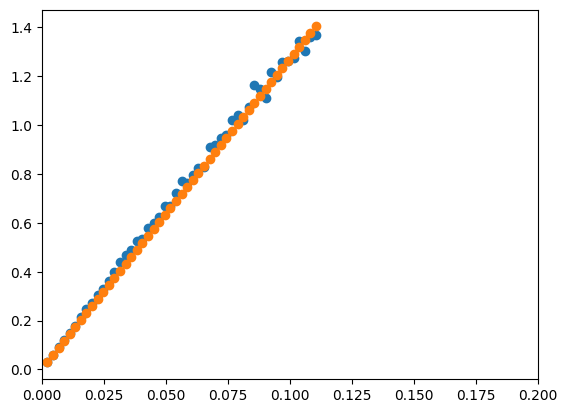

(0.0, 0.2)

In [14]:
scatter(qs[2:end], epsilons_default[2:end, 100] .- 1)
scatter(qs[2:end], 12.69*qs[2:end])
xlim(0, 0.2)
#ylim(0, 2)